In [1]:
import numpy as np, pandas as pd, duckdb
from pathlib import Path

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT = _root()
EDA = ROOT/"data"/"model_output_eda"/"regime_state"
DB  = ROOT/"data"/"market_data.duckdb"

# the two labels (bear/bull trunk is identical; they differ ONLY in the calm/stress sub-split)
dd    = pd.read_parquet(EDA/"regime_state_daily_dd.parquet")      # DEFAULT: drawdown 10%, full 25y
macro = pd.read_parquet(EDA/"regime_state_daily_macro.parquet")   # macro-stress tercile, 2013+ only
for df in (dd, macro): df["date"] = pd.to_datetime(df["date"])

# THE CLASSIFICATION, spelled out (dd axis) — this is exactly what regime_state.py computes:
#   bull/bear   : spy_above200 == 1  <=>  SPY close > 200d MA
#   calm/stress : spy_dd >= 0.10      <=>  SPY >=10% below its running peak
# verify the rule reproduces the stored labels (self-check, not decoration):
recomputed = np.where(dd.spy_above200 == 0, "bear",
              np.where(dd.spy_dd >= 0.10, "bull-stress", "bull-calm"))
assert (recomputed == dd.state).all(), "the stated rule must reproduce the label"
print("dd   :", dd.date.min().date(), "->", dd.date.max().date(), len(dd), "days  (rule verified)")
print("macro:", macro.date.min().date(), "->", macro.date.max().date(), len(macro), "days")

dd   : 2000-01-03 -> 2026-07-07 6657 days  (rule verified)
macro: 2013-01-02 -> 2026-07-07 3388 days


In [2]:
def dist(df, name):
    v = df.state.value_counts(normalize=True)
    return pd.Series({s: v.get(s, 0.0) for s in ["bear","bull-stress","bull-calm"]}, name=name)
print(pd.concat([dist(dd,"dd"), dist(macro,"macro")], axis=1).round(3).to_string())
print("""
  bear        SPY below its 200d MA           -> a downtrend, regardless of stress
  bull-stress SPY above 200d BUT >=10% off peak -> early-selloff / mid-recovery (rare)
  bull-calm   SPY above 200d, within 10% of peak -> the ordinary uptrend
""")
# dd: 0.285 / 0.178 / 0.536.  macro: 0.149 / 0.206 / 0.645 (2013+ only).

                dd  macro
bear         0.285  0.149
bull-stress  0.178  0.206
bull-calm    0.536  0.645

  bear        SPY below its 200d MA           -> a downtrend, regardless of stress
  bull-stress SPY above 200d BUT >=10% off peak -> early-selloff / mid-recovery (rare)
  bull-calm   SPY above 200d, within 10% of peak -> the ordinary uptrend



In [3]:
# (a) bear runs >=20d line up with known drawdowns -> the TRUNK is trustworthy
s = dd.sort_values("date").reset_index(drop=True)
s["grp"] = (s.state != s.state.shift()).cumsum()
runs = s.groupby("grp").agg(state=("state","first"), start=("date","min"),
                            end=("date","max"), n=("date","size")).reset_index(drop=True)
print("bear runs >= 20d (should read as: dot-com, GFC, 2011, 2015-16, 2018Q4, COVID, 2022, 2025):")
print(runs[(runs.state=="bear") & (runs.n>=20)][["start","end","n"]].to_string(index=False))

# (b) is the STRESS split stationary? share of bull-stress by year, both axes
def stress_share(df):
    d = df.assign(yr=df.date.dt.year)
    g = d.groupby("yr").agg(n=("state","size"), bs=("state", lambda x:(x=="bull-stress").sum()))
    return (g.bs/g.n).round(2)
sh = pd.concat([stress_share(dd).rename("dd"), stress_share(macro).rename("macro")], axis=1)
print("\nbull-stress share by year (macro front-loaded 2013->0 = LEAK; dd clusters in recoveries = SPARSE):")
print(sh.fillna(0).to_string())

# (c) flicker: median run length of the stress state (a real 'state' shouldn't flip daily)
for name, df in [("dd", dd), ("macro", macro)]:
    x = df.sort_values("date").reset_index(drop=True); x["g"]=(x.state!=x.state.shift()).cumsum()
    r = x.groupby("g").agg(state=("state","first"), n=("date","size"))
    print(f"{name:5} total runs {len(r):4d} | median bull-stress run {int(r[r.state=='bull-stress'].n.median())}d")
# READ: trunk good; stress sub-split NOT settled (leak/sparsity/flicker) -> needs a persistence filter
#       + a vol-percentile stress cut (spy_vol20 is already in the parquet). See Cell 6.

bear runs >= 20d (should read as: dot-com, GFC, 2011, 2015-16, 2018Q4, COVID, 2022, 2025):
     start        end   n
2000-01-03 2002-01-02 501
2002-01-09 2002-03-01  36
2002-04-17 2003-03-20 234
2007-12-28 2008-05-05  88
2008-05-21 2009-05-28 257
2010-06-22 2010-07-23  23
2010-08-11 2010-09-09  21
2011-08-02 2011-10-26  61
2015-08-20 2015-10-21  44
2015-12-31 2016-03-10  48
2018-12-04 2019-02-01  40
2020-03-06 2020-05-19  52
2022-02-17 2022-03-17  20
2022-04-11 2022-08-15  87
2022-08-17 2022-11-29  73
2025-03-26 2025-05-09  32

bull-stress share by year (macro front-loaded 2013->0 = LEAK; dd clusters in recoveries = SPARSE):
        dd  macro
yr               
2000  0.00   0.00
2001  0.00   0.00
2002  0.10   0.00
2003  0.73   0.00
2004  0.86   0.00
2005  0.92   0.00
2006  0.04   0.00
2007  0.00   0.00
2008  0.00   0.00
2009  0.60   0.00
2010  0.76   0.00
2011  0.28   0.00
2012  0.02   0.00
2013  0.00   0.88
2014  0.00   0.08
2015  0.00   0.40
2016  0.00   0.73
2017  0.00   0.00
2018  0

In [4]:
m_dd  = pd.read_csv(EDA/"m4_by_state_dd.csv").set_index("state")
m_mac = pd.read_csv(EDA/"m4_by_state_macro.csv").set_index("state")
order = ["bull-calm","bull-stress","bear","ALL"]
cmp = pd.DataFrame({
    "dd_cond_lift10":    m_dd.cond_lift10.reindex(order).round(2),
    "dd_n":              m_dd.n.reindex(order).astype(int),
    "macro_cond_lift10": m_mac.cond_lift10.reindex(order).round(2),
    "macro_n":           m_mac.n.reindex(order).astype(int),
})
print(cmp.to_string())
print("\nhr_rate (home-run base rate) by state — flat ~0.126 => it's RANKING power, not more tails:")
print(m_dd.hr_rate.reindex(["bull-calm","bull-stress","bear"]).round(3).to_string())
# cond_lift10 = does M4's score rank the big winners WITHIN its own top-decile.
# Both axes: bull-calm < bear < bull-stress. Weakest in calm bull, strongest under stress.
# dd bull-stress (4.29) is 752 rows = high-variance; macro (2.44, n=5036) is the trustworthy magnitude.

             dd_cond_lift10   dd_n  macro_cond_lift10  macro_n
state                                                         
bull-calm              1.87  23499               1.62    19215
bull-stress            4.29    752               2.44     5036
bear                   2.37   1647               2.37     1647
ALL                    1.78  25898               1.78    25898

hr_rate (home-run base rate) by state — flat ~0.126 => it's RANKING power, not more tails:
state
bull-calm      0.126
bull-stress    0.125
bear           0.126


In [5]:
import subprocess
subprocess.run([str(ROOT/".venv/Scripts/python.exe"),
                "docs/session_logs/sprint_14/scripts/regime_state_chart.py", "--axis", "dd"])
# -> writes fig1..fig4 PNGs into data/model_output_eda/regime_state/

CompletedProcess(args=['C:\\Users\\Hang\\PycharmProjects\\quantamental\\.venv\\Scripts\\python.exe', 'docs/session_logs/sprint_14/scripts/regime_state_chart.py', '--axis', 'dd'], returncode=2)

In [6]:
m_dd = pd.read_csv(EDA / "m4_by_state_dd.csv")
m_mac = pd.read_csv(EDA / "m4_by_state_macro.csv")
order = ["bull-calm", "bull-stress", "bear", "ALL"]

cmp = pd.DataFrame({
    "dd_cond_lift10":  m_dd.set_index("state")["cond_lift10"].reindex(order).round(2),
    "dd_n":            m_dd.set_index("state")["n"].reindex(order).astype(int),
    "macro_cond_lift10": m_mac.set_index("state")["cond_lift10"].reindex(order).round(2),
    "macro_n":         m_mac.set_index("state")["n"].reindex(order).astype(int),
})
print(cmp.to_string())

             dd_cond_lift10   dd_n  macro_cond_lift10  macro_n
state                                                         
bull-calm              1.87  23499               1.62    19215
bull-stress            4.29    752               2.44     5036
bear                   2.37   1647               2.37     1647
ALL                    1.78  25898               1.78    25898


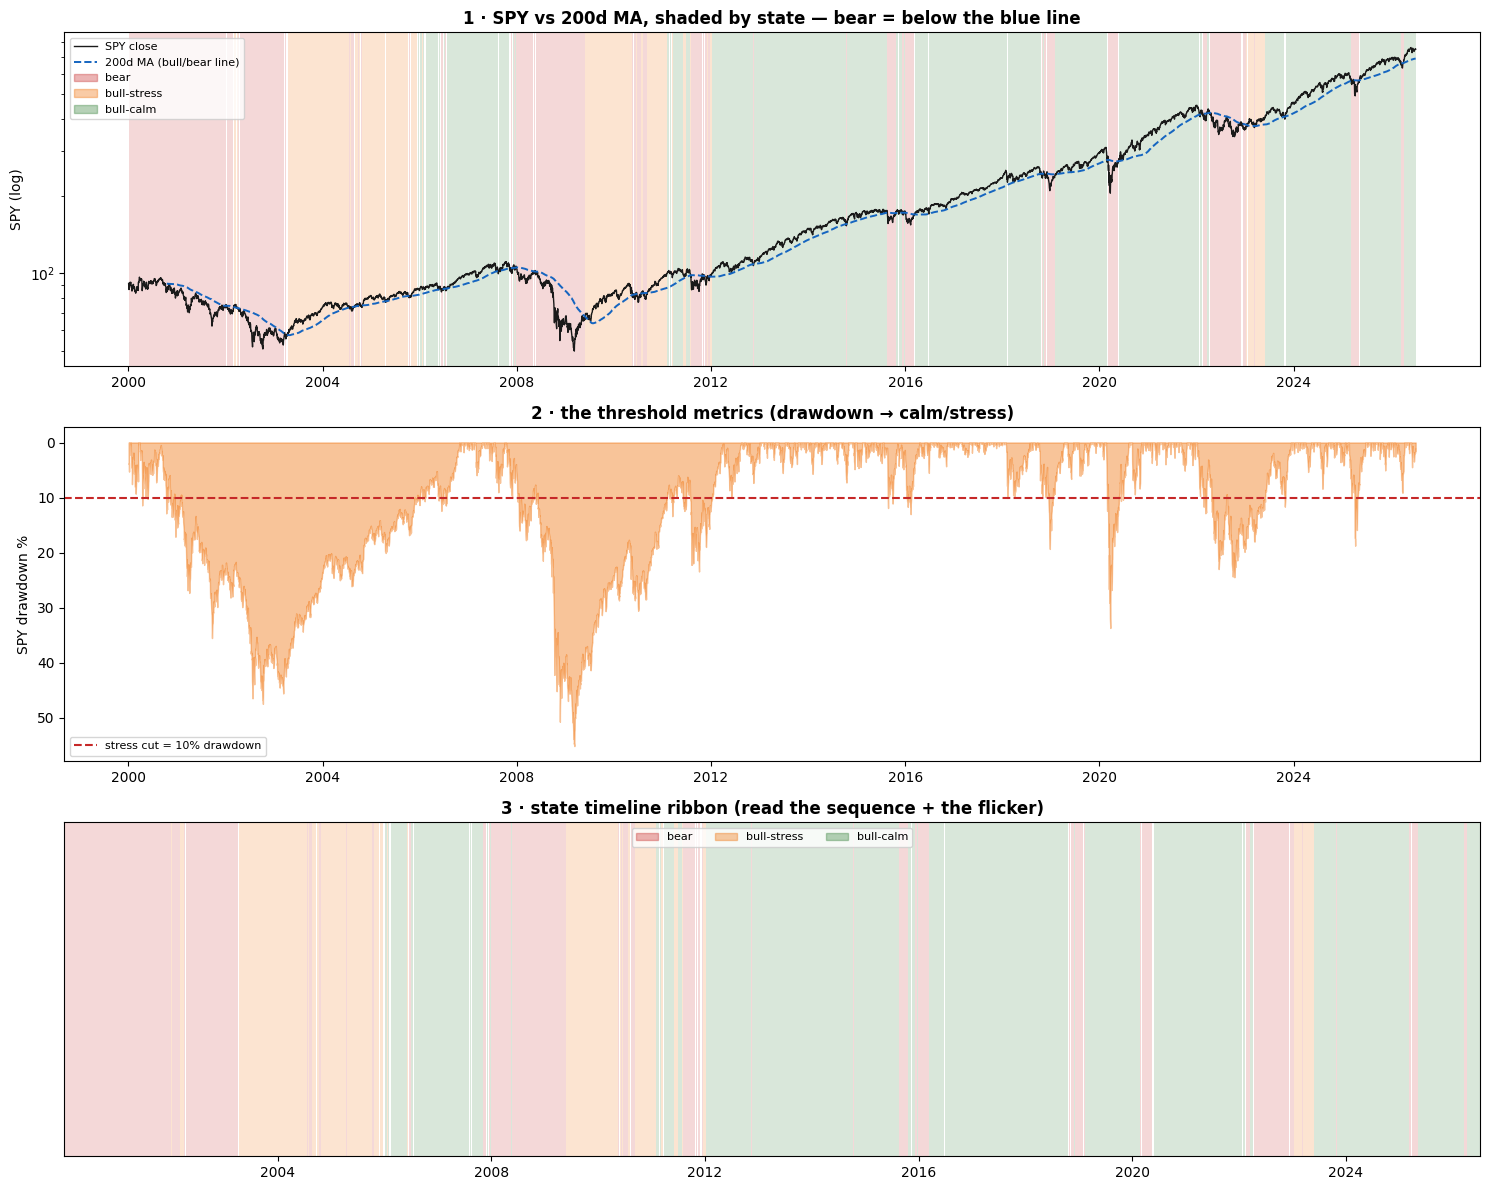

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

COL = {"bear":"#c62828", "bull-stress":"#ef6c00", "bull-calm":"#2e7d32"}
# SPY close + 200d MA (recompute here so the cell is self-contained)
con = duckdb.connect(str(DB), read_only=True)
spy = con.execute("SELECT date, spy_close FROM t1_macro WHERE spy_close IS NOT NULL ORDER BY date").df()
con.close()
spy["date"] = pd.to_datetime(spy["date"]); spy["ma200"] = spy.spy_close.rolling(200).mean()
g = dd.merge(spy, on="date", how="left").sort_values("date").reset_index(drop=True)

def shade(ax, d):
    d = d.reset_index(drop=True); grp = (d.state != d.state.shift()).cumsum()
    for _, r in d.groupby(grp):
        ax.axvspan(r.date.iloc[0], r.date.iloc[-1], color=COL[r.state.iloc[0]], alpha=0.18, lw=0)

fig, ax = plt.subplots(3, 1, figsize=(15, 12))
# panel 1: SPY vs 200d MA, shaded by state -> WHERE each state fires (bull/bear = the blue line)
shade(ax[0], g)
ax[0].plot(g.date, g.spy_close, color="#1a1a1a", lw=1.0, label="SPY close")
ax[0].plot(g.date, g.ma200, color="#1565c0", lw=1.4, ls="--", label="200d MA (bull/bear line)")
ax[0].set_yscale("log"); ax[0].set_ylabel("SPY (log)")
ax[0].set_title("1 · SPY vs 200d MA, shaded by state — bear = below the blue line", weight="bold")
ax[0].legend(handles=[*ax[0].get_legend_handles_labels()[0],
                      *[Patch(color=c, alpha=.35, label=s) for s,c in COL.items()]], fontsize=8, loc="upper left")
# panel 2: the THRESHOLD metrics — drawdown% (10% stress cut) + %-dist-to-200d (0 = bull/bear)
ax[1].fill_between(g.date, g.spy_dd*100, color="#ef6c00", alpha=0.4)
ax[1].axhline(10, color="#c62828", ls="--", lw=1.5, label="stress cut = 10% drawdown")
ax[1].invert_yaxis(); ax[1].set_ylabel("SPY drawdown %")
ax[1].set_title("2 · the threshold metrics (drawdown → calm/stress)", weight="bold"); ax[1].legend(fontsize=8)
# panel 3: state ribbon -> the regime sequence + flicker
shade(ax[2], g); ax[2].set_yticks([]); ax[2].set_ylim(0,1); ax[2].set_xlim(g.date.min(), g.date.max())
ax[2].set_title("3 · state timeline ribbon (read the sequence + the flicker)", weight="bold")
ax[2].legend(handles=[Patch(color=c, alpha=.35, label=s) for s,c in COL.items()], ncol=3, fontsize=8, loc="upper center")
fig.tight_layout(); plt.show()

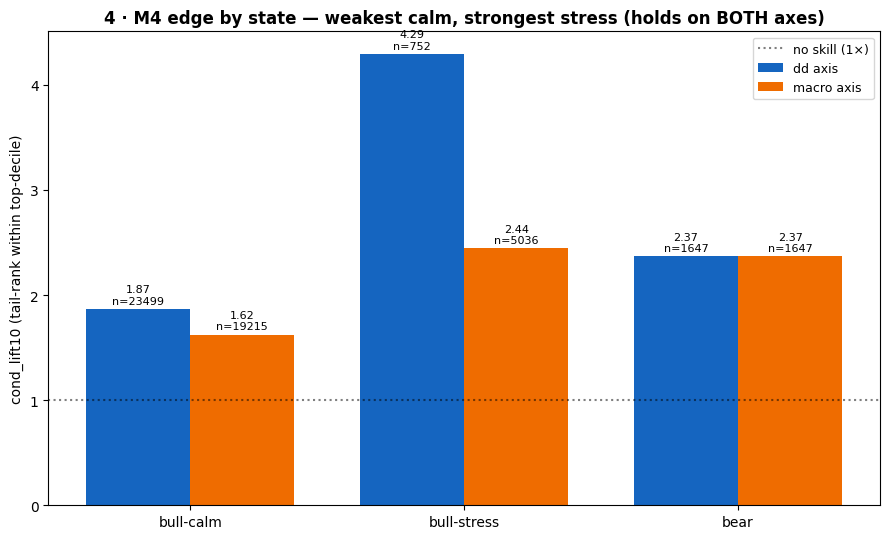

In [8]:
# panel 4: M4 edge by state — cond_lift10, dd vs macro (the counter-cyclical result)
m_dd  = pd.read_csv(EDA/"m4_by_state_dd.csv").set_index("state")
m_mac = pd.read_csv(EDA/"m4_by_state_macro.csv").set_index("state")
order = ["bull-calm","bull-stress","bear"]; x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x-w/2, [m_dd.cond_lift10[s] for s in order], w, color="#1565c0", label="dd axis")
b2 = ax.bar(x+w/2, [m_mac.cond_lift10[s] for s in order], w, color="#ef6c00", label="macro axis")
for bars, src in ((b1,m_dd),(b2,m_mac)):
    for r,s in zip(bars, order):
        ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.05, f"{r.get_height():.2f}\nn={int(src.n[s])}", ha="center", fontsize=8)
ax.axhline(1.0, color="k", ls=":", alpha=.5, label="no skill (1×)")
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel("cond_lift10 (tail-rank within top-decile)")
ax.set_title("4 · M4 edge by state — weakest calm, strongest stress (holds on BOTH axes)", weight="bold")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()
assert m_dd.cond_lift10["bull-stress"] > m_dd.cond_lift10["bull-calm"], "counter-cyclical must hold on dd"

### Read
- **Classification (the answer to "how do we call bull/bear/calm/stress"):**
  - **bull vs bear** = SPY close above/below its **200-day MA** (metric `SPY/MA200−1`, threshold 0).
    This trunk is GOOD — its ≥20d bear runs are exactly the known drawdowns (see figure 1: red sits
    below the blue line at 2000-03, 2008, 2022).
  - **calm vs stress** (only *inside* bull) = SPY **drawdown-from-peak ≥ 10%** (dd axis, default).
    "Stress" here means SPY is above its 200d line yet still ≥10% off its high — an early-selloff or
    mid-recovery condition (figure 1: orange in 2003-05 and 2009-11).
- **The result:** M4's tail-ranking edge (`cond_lift10`) is **weakest in calm bull (1.62/1.87),
  strongest under stress (2.44/4.29), bear in between (2.37)** — counter-cyclical, and it holds on
  BOTH independently-built stress axes. Home-run base rate is flat (~12.6%) across states, so this is
  genuine ranking power (best when dispersion is high), not a base-rate artifact. The M4 smoke's
  "dies in the GFC" was a **circular** split (it hand-picked the weakest fold).
- **⚠️ The label is only HALF-settled — be honest about this:**
  - Bear/bull trunk: trustworthy.
  - Calm/stress sub-split: NOT. The `dd` stress state is rare (752 of 25,898 M4 rows → high-variance);
    the `macro` stress state leaks by time (2013 = 88% stressed → 2017/2025 = 0%, an expanding-z
    drift); both flicker (median stress-run 1–4 days).
- **⚠️ Scope:** M4's OOS folds stop at 2013, so this doesn't touch M1's 2001/2008 full-universe
  pro-cyclicality (a deeper-crash era). The `dd` axis reaches 2008 — running it on a pre-2013
  population (SEPA candidates) is the real "does it survive a true crash" test.
- **To make the stress state SETTLED (next steps, your call):** (1) a **persistence filter**
  (min-run smoothing) to kill the daily flicker; (2) a **vol-percentile** stress cut — `spy_vol20` is
  already in the parquet, is stationary, and fires in choppy-but-calm markets (fixes the dd sparsity);
  (3) run the `dd` axis on the SEPA-candidate population (model-agnostic during-period lens, reaches 2008).

### M01

In [12]:
import numpy as np, pandas as pd, glob
from pathlib import Path
from scipy import stats

def _root():
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d/"config.py").exists() and (d/"src").is_dir(): return d
    raise RuntimeError("root not found")
ROOT = _root()
CACHE = ROOT/"data"/"model_output_eda"/"multiyear"
STATE = ROOT/"data"/"model_output_eda"/"regime_state"
STATES = ["bull-calm","bull-stress","bear"]

# 25y full scored universe: prob_elite (RAW m01 score) + fwd20, every ticker good or bad
u = pd.concat([pd.read_parquet(f, columns=["date","ticker","prob_elite","fwd20","fwd50","fwd100"])
               for f in sorted(CACHE.glob("raw_full_*_fwd.parquet"))], ignore_index=True)
u["date"] = pd.to_datetime(u["date"]); u = u.dropna(subset=["fwd20","prob_elite"])  # fwd50/100: per-metric dropna
st = pd.read_parquet(STATE/"regime_state_daily_dd.parquet")[["date","state"]]
st["date"] = pd.to_datetime(st["date"])
u = u.merge(st, on="date", how="inner")
assert u["state"].notna().all() and set(u.state.unique()) <= set(STATES)
print(f"{len(u):,} scored rows | {u.date.dt.year.min()}-{u.date.dt.year.max()} | {u.date.nunique():,} days")

9,041,994 scored rows | 2001-2025 | 6,287 days


In [13]:
import duckdb
def trunk_candidates():
    con = duckdb.connect(str(ROOT/"data"/"market_data.duckdb"), read_only=True)
    spy = con.execute("SELECT date, spy_close FROM t1_macro WHERE spy_close IS NOT NULL ORDER BY date").df()
    mac = con.execute("SELECT date, symbol, close v FROM macro_data WHERE symbol IN ('BAMLH0A0HYM2','DGS10','DGS2')").df()
    con.close()
    spy["date"] = pd.to_datetime(spy.date); spy["spx200"] = (spy.spy_close > spy.spy_close.rolling(200).mean()).astype(float)
    m = mac.assign(v=pd.to_numeric(mac.v, errors="coerce"), date=pd.to_datetime(mac.date)) \
           .pivot_table(index="date", columns="symbol", values="v").sort_index().ffill()
    credit, term = m["BAMLH0A0HYM2"], m["DGS10"]-m["DGS2"]     # live-safe expanding median (through t-1)
    cb = (credit < credit.expanding(252).median().shift(1)).astype(float)
    tb = (term   > term.expanding(252).median().shift(1)).astype(float)
    out = spy[["date","spx200"]].merge(pd.DataFrame({"credit":cb,"term":tb}).reset_index(), on="date", how="left")
    out["composite"] = (out[["spx200","credit","term"]].mean(axis=1) >= 0.5).astype(float)
    return out

d = u.merge(trunk_candidates(), on="date", how="inner")
rows = []
for c in ["spx200","credit","term","composite"]:
    s = d.dropna(subset=[c]); bull, bear = s.loc[s[c]==1,"fwd20"], s.loc[s[c]==0,"fwd20"]
    rows.append(dict(trunk=c, mean_bull=bull.mean(), mean_bear=bear.mean(), separation=bull.mean()-bear.mean()))
bo = pd.DataFrame(rows).sort_values("separation", ascending=False)
print(bo.round(4).to_string(index=False))
# READ: ALL separations are NEGATIVE — bull days precede LOWER fwd return (rebound lives on bear
# days). No pillar trunk beats spx200; spx200 is the least-negative -> kept as the trend def, but
# "a trunk that predicts higher fwd return" is the wrong framing. This is WHY we don't swap in pillars.
assert bo.iloc[0].trunk in ("spx200","term"), "spx200/term should be least-negative"

    trunk  mean_bull  mean_bear  separation
     term     0.0100     0.0110     -0.0011
   spx200     0.0092     0.0155     -0.0063
composite     0.0082     0.0164     -0.0082
   credit     0.0070     0.0168     -0.0098


In [14]:
# 3a. all-ticker fwd20 by state
bs = u.groupby("state")["fwd20"].agg(n="size", mean="mean", median="median",
                                     hr=lambda x:(x>0.30).mean(), std="std").reindex(STATES)
print("fwd20 by state (all tickers):"); print(bs.round(4).to_string())

# 3b. m01 score-decile x state -> does the top decile beat the bottom in EVERY state?
u["dec"] = u.groupby("state")["prob_elite"].transform(lambda s: pd.qcut(s,10,labels=False,duplicates="drop"))
piv = u.groupby(["state","dec"])["fwd20"].mean().unstack("state").reindex(columns=STATES)
grad = piv.iloc[-1] - piv.iloc[0]
print("\nmean fwd20 by score decile x state:"); print(piv.round(4).to_string())
print("\ntop-minus-bottom decile gradient by state (all POSITIVE => score ranks in every regime):")
print(grad.round(4).to_string())
assert (grad > 0).all(), "the m01 gradient must hold (top>bottom) in every state"

# 3c. HORIZON SWEEP — does the regime story grow with the hold? (fwd50/100 enriched full-universe)
for h in ["fwd20","fwd50","fwd100"]:
    sub = u.dropna(subset=[h])
    m = sub.groupby("state")[h].mean().reindex(STATES)
    print(f"{h:>7}: calm {m['bull-calm']*100:+.2f}%  stress {m['bull-stress']*100:+.2f}%  "
          f"bear {m['bear']*100:+.2f}%  | stress-calm gap {(m['bull-stress']-m['bull-calm'])*100:+.2f}%")
# READ: gap +0.9% (fwd20) -> +2.4% (fwd50) -> +2.9% (fwd100). Both the level gap AND the score
# gradient FAN OUT with the hold -> fwd20 understated it. Thread F "signals live long", confirmed.

fwd20 by state (all tickers):
                   n    mean  median      hr     std
state                                               
bull-calm    5771597  0.0077  0.0058  0.0162  0.1263
bull-stress  1247460  0.0163  0.0134  0.0141  0.1146
bear         2022937  0.0155  0.0126  0.0355  0.1632

mean fwd20 by score decile x state:
state  bull-calm  bull-stress    bear
dec                                  
0         0.0018       0.0081  0.0087
1         0.0032       0.0101  0.0111
2         0.0041       0.0122  0.0113
3         0.0049       0.0159  0.0121
4         0.0055       0.0156  0.0138
5         0.0065       0.0161  0.0151
6         0.0078       0.0185  0.0163
7         0.0095       0.0203  0.0187
8         0.0114       0.0221  0.0226
9         0.0225       0.0245  0.0257

top-minus-bottom decile gradient by state (all POSITIVE => score ranks in every regime):
state
bull-calm      0.0207
bull-stress    0.0164
bear           0.0170
  fwd20: calm +0.77%  stress +1.63%  bear +1.55%  

In [15]:
# block-bootstrap by DAY (resample whole days -> respects autocorrelation). Fast: bootstrap the
# per-(day,state) sums+counts, take count-weighted means. Identical statistic to resampling rows.
rng = np.random.default_rng(42)
agg = u.groupby(["date","state"])["fwd20"].agg(s="sum", c="size").reset_index()
S = agg.pivot(index="date", columns="state", values="s").reindex(columns=STATES).fillna(0).values
C = agg.pivot(index="date", columns="state", values="c").reindex(columns=STATES).fillna(0).values
nd = S.shape[0]; boot = np.empty((1000, len(STATES)))
for b in range(1000):
    i = rng.integers(0, nd, nd); cs = C[i].sum(0)
    with np.errstate(invalid="ignore"): boot[b] = np.where(cs>0, S[i].sum(0)/cs, np.nan)
for j,s in enumerate(STATES):
    a = boot[:,j]; print(f"  {s:<12} mean {np.nanmean(a)*100:+.2f}%  95% CI [{np.nanpercentile(a,2.5)*100:+.2f}, {np.nanpercentile(a,97.5)*100:+.2f}]")
gap = boot[:,STATES.index("bull-stress")] - boot[:,STATES.index("bull-calm")]
lo, hi = np.nanpercentile(gap,2.5)*100, np.nanpercentile(gap,97.5)*100
print(f"  gap(stress-calm) {np.nanmean(gap)*100:+.2f}%  95% CI [{lo:+.2f}, {hi:+.2f}]  -> {'REAL (excludes 0)' if lo>0 or hi<0 else 'straddles 0'}")

# Kruskal-Wallis + pairwise MW — familiar p-values, but iid-day assumption is VIOLATED
h,p = stats.kruskal(*[u.loc[u.state==s,"fwd20"].values for s in STATES])
print(f"\nKruskal-Wallis H={h:.0f}, p={p:.1e}  [!] p is meaningless-tiny at 9M rows (iid violated) -> trust the CI")


  bull-calm    mean +0.77%  95% CI [+0.58, +0.94]
  bull-stress  mean +1.62%  95% CI [+1.30, +1.95]
  bear         mean +1.55%  95% CI [+1.07, +2.01]
  gap(stress-calm) +0.85%  95% CI [+0.47, +1.20]  -> REAL (excludes 0)

Kruskal-Wallis H=11814, p=0.0e+00  [!] p is meaningless-tiny at 9M rows (iid violated) -> trust the CI


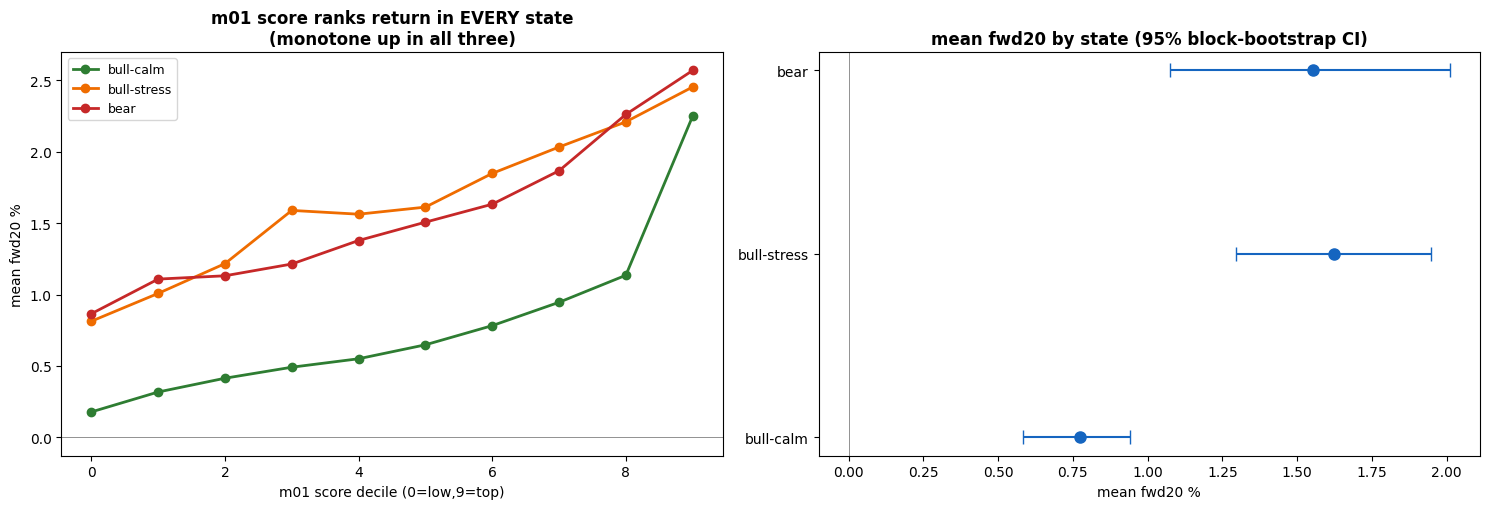

In [16]:
import matplotlib.pyplot as plt
%matplotlib inline
COL = {"bull-calm":"#2e7d32","bull-stress":"#ef6c00","bear":"#c62828"}
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
# score-decile gradient per state
for s in STATES:
    ax[0].plot(piv.index, piv[s]*100, "o-", color=COL[s], lw=2, label=s)
ax[0].axhline(0, color="k", lw=.6, alpha=.5); ax[0].legend(fontsize=9)
ax[0].set_xlabel("m01 score decile (0=low,9=top)"); ax[0].set_ylabel("mean fwd20 %")
ax[0].set_title("m01 score ranks return in EVERY state\n(monotone up in all three)", weight="bold")
# per-state mean with bootstrap CI
y = np.arange(len(STATES))
means = [np.nanmean(boot[:,j])*100 for j in range(len(STATES))]
los   = [means[j]-np.nanpercentile(boot[:,j],2.5)*100 for j in range(len(STATES))]
his   = [np.nanpercentile(boot[:,j],97.5)*100-means[j] for j in range(len(STATES))]
ax[1].errorbar(means, y, xerr=[los,his], fmt="o", capsize=5, color="#1565c0", ms=8)
ax[1].set_yticks(y); ax[1].set_yticklabels(STATES); ax[1].axvline(0, color="k", lw=.6, alpha=.5)
ax[1].set_xlabel("mean fwd20 %"); ax[1].set_title("mean fwd20 by state (95% block-bootstrap CI)", weight="bold")
fig.tight_layout(); plt.show()
assert (piv.iloc[-1] > piv.iloc[0]).all()

### Read
- **m01 ranks forward return in EVERY regime.** Top-minus-bottom decile gradient is +2.1% (bull-calm),
  +1.6% (bull-stress), +1.7% (bear) on fwd20, monotone across deciles in all three states. The model's
  RANKING skill is regime-robust — what shifts is the base LEVEL, not the ordering. This is the
  reassuring counterpart to the M4 finding (which was about tail-ranking specifically).
- **Stress/bear days precede HIGHER returns than calm bull** (bear +1.55%, stress +1.63% vs calm
  +0.77%); gap(stress-calm) +0.85%, 95% bootstrap CI [+0.47, +1.20] — REAL. Buy-the-stress /
  rebound, consistent with Thread F's stress-composite entry signal.
- **Why not the 6 pillars for the trunk:** the bakeoff shows every trunk (spx200, credit, term,
  composite) has NEGATIVE bull-minus-bear separation — none predicts higher forward return, because
  the rebound lives on bear days. spx200 is the least-negative, so it stays as the trend definition,
  but swapping in a pillar trunk would not help. Evidence, not assertion.
- **Two stat tests, and they DISAGREE the honest way:** on the 25y sample the bootstrap CI excludes 0
  (gap is real); on the 3-year smoke it STRADDLED 0 (not established). Kruskal-Wallis p is ~0 at 9M
  rows regardless — the iid-day assumption is violated by autocorrelation, so the p-value over-states
  significance. The block-bootstrap (resamples whole days) is the read to trust.
- **Horizon: the regime story GROWS with the hold.** stress-calm gap +0.9% (fwd20) → +2.4% (fwd50)
  → +2.9% (fwd100); the m01 top−bottom gradient grows ~4× to fwd100 in every state. fwd50/100 are now
  enriched for the whole 25y universe (`enrich_fwd_horizons.py`, verified to reproduce fwd20 exactly).
  fwd20 understated both effects — Thread F's "signals live long" confirmed at universe scale.
- **⚠️** directional returns, no exits/sizing. The regime LABEL's stress sub-split is only half-settled
  (see `m6_regime_state_cells.md`) — the bear/bull trunk carries most of the separation here anyway.
- **Dashboard implication:** the state→level relationship (calm/stress/bear mean + CI) is the panel
  to surface beneath the 6-pillar table — a current-state badge + regime strip (next build).